<a href="https://colab.research.google.com/github/Sreelakshmijayarajan/Conference_eye_classification/blob/main/eye_conference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.lower().endswith('.zip'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Uveitis.zip
/content/drive/MyDrive/glaucoma and normal.zip


In [3]:
import os

zip1 = '/content/drive/MyDrive/Uveitis.zip'
zip2 = '/content/drive/MyDrive/glaucoma and normal.zip'

print("Uveitis ZIP exists:", os.path.exists(zip1))
print("Normal + Glaucoma ZIP exists:", os.path.exists(zip2))

Uveitis ZIP exists: True
Normal + Glaucoma ZIP exists: True


In [4]:
import os
import shutil

base = '/content/final_dataset'

if os.path.exists(base):
    shutil.rmtree(base)
    print("Old dataset removed successfully")
else:
    print("No old dataset found")

No old dataset found


In [5]:
import os

base = '/content/final_dataset'

for class_name in ['normal', 'glaucoma', 'uveitis']:
    os.makedirs(os.path.join(base, class_name), exist_ok=True)

print("New dataset structure created successfully!")

New dataset structure created successfully!


In [6]:
import zipfile
import os

for zip_path in [zip1, zip2]:

    print("\n==============================")
    print("ZIP:", os.path.basename(zip_path))

    with zipfile.ZipFile(zip_path, 'r') as z:
        folders = set()

        for file in z.namelist():
            parts = file.split('/')

            if len(parts) >= 2:
                folders.add(parts[0])

        for folder in sorted(folders):
            print("-", folder)


ZIP: Uveitis.zip
- Uveitis

ZIP: glaucoma and normal.zip
- dataset


In [7]:
import zipfile

with zipfile.ZipFile(zip2, 'r') as z:

    folders = set()

    for file in z.namelist():
        parts = file.split('/')

        if len(parts) >= 3:
            folders.add('/'.join(parts[:3]))

    for folder in sorted(folders):
        print(folder)

dataset/cataract/0_left.jpg
dataset/cataract/103_left.jpg
dataset/cataract/1062_right.jpg
dataset/cataract/1083_left.jpg
dataset/cataract/1084_right.jpg
dataset/cataract/1102_left.jpg
dataset/cataract/1102_right.jpg
dataset/cataract/1115_left.jpg
dataset/cataract/1126_right.jpg
dataset/cataract/112_right.jpg
dataset/cataract/1144_left.jpg
dataset/cataract/1144_right.jpg
dataset/cataract/1164_left.jpg
dataset/cataract/1167_right.jpg
dataset/cataract/119_left.jpg
dataset/cataract/1285_left.jpg
dataset/cataract/1415_left.jpg
dataset/cataract/1415_right.jpg
dataset/cataract/1435_left.jpg
dataset/cataract/1444_left.jpg
dataset/cataract/1452_left.jpg
dataset/cataract/1454_right.jpg
dataset/cataract/1456_left.jpg
dataset/cataract/1460_right.jpg
dataset/cataract/1468_left.jpg
dataset/cataract/1483_right.jpg
dataset/cataract/1484_left.jpg
dataset/cataract/1484_right.jpg
dataset/cataract/1490_right.jpg
dataset/cataract/188_right.jpg
dataset/cataract/1968_left.jpg
dataset/cataract/1987_left.jpg
d

In [8]:
import zipfile
import os
import shutil

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

with zipfile.ZipFile(zip2, 'r') as z:

    for file in z.namelist():

        if not file.lower().endswith(valid_extensions):
            continue

        filename = os.path.basename(file)

        if '/normal/' in file.lower():
            destination = os.path.join(base, 'normal', filename)

        elif '/glaucoma/' in file.lower():
            destination = os.path.join(base, 'glaucoma', filename)

        else:
            continue

        with z.open(file) as source:
            with open(destination, 'wb') as target:
                shutil.copyfileobj(source, target)

print("Normal and Glaucoma extraction completed!")

Normal and Glaucoma extraction completed!


In [9]:
import zipfile
import os
import shutil

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

with zipfile.ZipFile(zip1, 'r') as z:

    for file in z.namelist():

        if not file.lower().endswith(valid_extensions):
            continue

        filename = os.path.basename(file)
        destination = os.path.join(base, 'uveitis', filename)

        with z.open(file) as source:
            with open(destination, 'wb') as target:
                shutil.copyfileobj(source, target)

print("New Uveitis extraction completed!")

New Uveitis extraction completed!


In [10]:
import zipfile

with zipfile.ZipFile(zip2, 'r') as z:

    folders = set()

    for file in z.namelist():
        parts = file.split('/')

        if len(parts) >= 3:
            folders.add('/'.join(parts[:3]))

    for folder in sorted(folders):
        print(folder)

dataset/cataract/0_left.jpg
dataset/cataract/103_left.jpg
dataset/cataract/1062_right.jpg
dataset/cataract/1083_left.jpg
dataset/cataract/1084_right.jpg
dataset/cataract/1102_left.jpg
dataset/cataract/1102_right.jpg
dataset/cataract/1115_left.jpg
dataset/cataract/1126_right.jpg
dataset/cataract/112_right.jpg
dataset/cataract/1144_left.jpg
dataset/cataract/1144_right.jpg
dataset/cataract/1164_left.jpg
dataset/cataract/1167_right.jpg
dataset/cataract/119_left.jpg
dataset/cataract/1285_left.jpg
dataset/cataract/1415_left.jpg
dataset/cataract/1415_right.jpg
dataset/cataract/1435_left.jpg
dataset/cataract/1444_left.jpg
dataset/cataract/1452_left.jpg
dataset/cataract/1454_right.jpg
dataset/cataract/1456_left.jpg
dataset/cataract/1460_right.jpg
dataset/cataract/1468_left.jpg
dataset/cataract/1483_right.jpg
dataset/cataract/1484_left.jpg
dataset/cataract/1484_right.jpg
dataset/cataract/1490_right.jpg
dataset/cataract/188_right.jpg
dataset/cataract/1968_left.jpg
dataset/cataract/1987_left.jpg
d

In [11]:
import os

for folder in ['normal', 'glaucoma', 'uveitis']:
    path = os.path.join(base, folder)

    count = len([
        f for f in os.listdir(path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    print(folder, ":", count)

normal : 1074
glaucoma : 1007
uveitis : 100


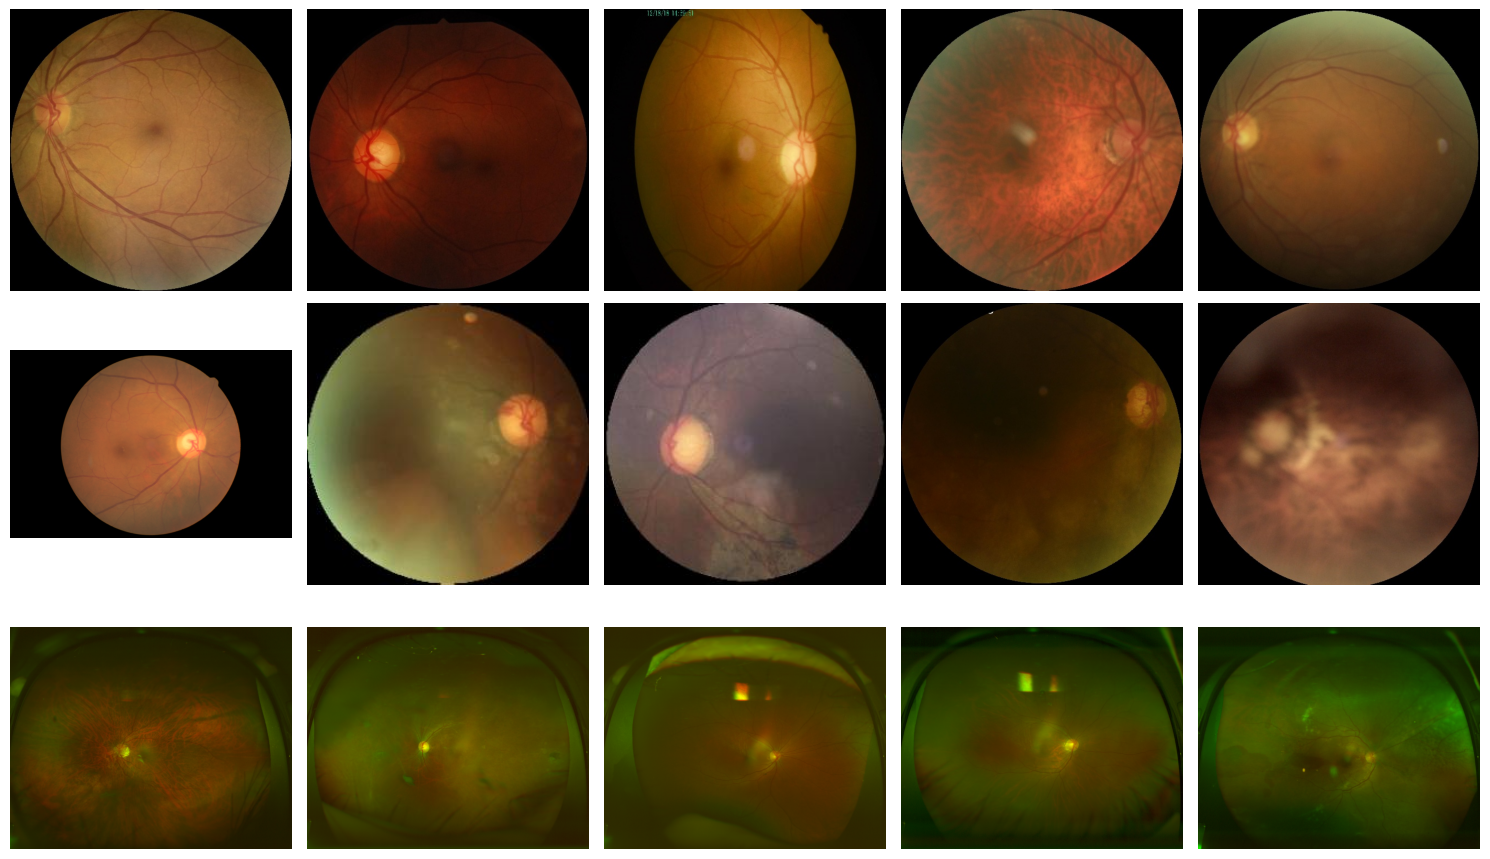

In [12]:
import os
import matplotlib.pyplot as plt
from PIL import Image

classes = ['normal', 'glaucoma', 'uveitis']

plt.figure(figsize=(15, 9))

for row, class_name in enumerate(classes):
    folder = os.path.join(base, class_name)

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ][:5]

    for col, image_name in enumerate(images):
        image_path = os.path.join(folder, image_name)
        image = Image.open(image_path)

        plt.subplot(3, 5, row * 5 + col + 1)
        plt.imshow(image)
        plt.axis('off')

        if col == 0:
            plt.ylabel(class_name, fontsize=12)

plt.tight_layout()
plt.show()

In [13]:
import os
import shutil
import random

random.seed(42)

source_dir = '/content/final_dataset'
split_dir = '/content/split_dataset'

classes = ['normal', 'glaucoma', 'uveitis']

# Already split folder இருந்தால் remove செய்யும்
if os.path.exists(split_dir):
    shutil.rmtree(split_dir)

# Create train, val, test folders
for split in ['train', 'val', 'test']:
    for class_name in classes:
        os.makedirs(
            os.path.join(split_dir, split, class_name),
            exist_ok=True
        )

# Split each class
for class_name in classes:

    class_path = os.path.join(source_dir, class_name)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    random.shuffle(images)

    total = len(images)

    train_end = int(0.70 * total)
    val_end = train_end + int(0.15 * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    split_images = {
        'train': train_images,
        'val': val_images,
        'test': test_images
    }

    for split, image_list in split_images.items():

        destination_folder = os.path.join(
            split_dir,
            split,
            class_name
        )

        for image_name in image_list:

            source_path = os.path.join(
                class_path,
                image_name
            )

            destination_path = os.path.join(
                destination_folder,
                image_name
            )

            shutil.copy2(source_path, destination_path)

    print(
        class_name,
        "→ Train:", len(train_images),
        "| Val:", len(val_images),
        "| Test:", len(test_images)
    )

print("\nDataset splitting completed!")

normal → Train: 751 | Val: 161 | Test: 162
glaucoma → Train: 704 | Val: 151 | Test: 152
uveitis → Train: 70 | Val: 15 | Test: 15

Dataset splitting completed!


In [14]:
for split in ['train', 'val', 'test']:

    print("\n", split.upper())

    for class_name in classes:

        folder = os.path.join(
            split_dir,
            split,
            class_name
        )

        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

        print(class_name, ":", count)


 TRAIN
normal : 751
glaucoma : 704
uveitis : 70

 VAL
normal : 161
glaucoma : 151
uveitis : 15

 TEST
normal : 162
glaucoma : 152
uveitis : 15


In [15]:
import torch
import torchvision
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128


In [16]:
image_size = 224

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomResizedCrop(
        image_size,
        scale=(0.85, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [17]:
train_dir = '/content/split_dataset/train'
val_dir = '/content/split_dataset/val'
test_dir = '/content/split_dataset/test'

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transform
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Classes: ['glaucoma', 'normal', 'uveitis']
Class mapping: {'glaucoma': 0, 'normal': 1, 'uveitis': 2}
Train images: 1525
Validation images: 327
Test images: 329


In [18]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [19]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels[:10])

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Labels: tensor([0, 1, 1, 0, 1, 0, 0, 1, 2, 1])


In [20]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Training will use CPU.")

Device: cuda
GPU Name: Tesla T4


In [21]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [22]:
!pip install -q timm

In [23]:
import torch
import torch.nn as nn
import timm

In [24]:
efficientnet_model = timm.create_model(
    'tf_efficientnetv2_s',
    pretrained=True,
    num_classes=0
)

densenet_model = timm.create_model(
    'densenet201',
    pretrained=True,
    num_classes=0
)

print("EfficientNetV2-S loaded successfully")
print("DenseNet-201 loaded successfully")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 86.5MB            

model.safetensors: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B / 81.1MB            

model.safetensors: downloading bytes:           |  0.00B            

EfficientNetV2-S loaded successfully
DenseNet-201 loaded successfully


In [25]:
print(
    "EfficientNetV2-S feature dimension:",
    efficientnet_model.num_features
)

print(
    "DenseNet-201 feature dimension:",
    densenet_model.num_features
)

EfficientNetV2-S feature dimension: 1280
DenseNet-201 feature dimension: 1920


In [26]:
class CoordinateAttention(nn.Module):
    def __init__(self, channels, reduction=32):
        super().__init__()

        reduced_channels = max(8, channels // reduction)

        self.conv1 = nn.Conv1d(
            channels,
            reduced_channels,
            kernel_size=1
        )

        self.bn1 = nn.BatchNorm1d(reduced_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv_attention = nn.Conv1d(
            reduced_channels,
            channels,
            kernel_size=1
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: [batch_size, channels]
        x = x.unsqueeze(-1)

        attention = self.conv1(x)
        attention = self.bn1(attention)
        attention = self.relu(attention)

        attention = self.conv_attention(attention)
        attention = self.sigmoid(attention)

        x = x * attention

        return x.squeeze(-1)

In [27]:
class FusionModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        # Pretrained feature extractors
        self.efficientnet = timm.create_model(
            'tf_efficientnetv2_s',
            pretrained=True,
            num_classes=0
        )

        self.densenet = timm.create_model(
            'densenet201',
            pretrained=True,
            num_classes=0
        )

        # Feature dimensions
        efficientnet_features = self.efficientnet.num_features
        densenet_features = self.densenet.num_features

        fusion_features = (
            efficientnet_features + densenet_features
        )

        # Coordinate Attention
        self.coordinate_attention = CoordinateAttention(
            channels=fusion_features
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(fusion_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        # Extract features from both models
        features_efficientnet = self.efficientnet(x)
        features_densenet = self.densenet(x)

        # Concatenate features
        fused_features = torch.cat(
            [
                features_efficientnet,
                features_densenet
            ],
            dim=1
        )

        # Apply Coordinate Attention
        attended_features = self.coordinate_attention(
            fused_features
        )

        # Final classification
        output = self.classifier(attended_features)

        return output

In [28]:
model = FusionModel(num_classes=3)

model = model.to(device)

print(model)

FusionModel(
  (efficientnet): EfficientNet(
    (conv_stem): Conv2dSame(3, 24, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn1): BatchNormAct2d(
      24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): ConvBnAct(
          (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNormAct2d(
            24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (drop_path): Identity()
        )
        (1): ConvBnAct(
          (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNormAct2d(
            24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (a

In [29]:
model = FusionModel(num_classes=3)
model = model.to(device)

print("Fusion model created successfully!")

Fusion model created successfully!


In [30]:
model.eval()

print("Model is ready for testing!")

Model is ready for testing!


In [31]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels:", labels)
print("Predictions:", torch.argmax(outputs, dim=1))

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 3])
Labels: tensor([0, 1, 1, 0, 0, 0, 2, 1, 1, 0, 1, 0, 0, 0, 1, 1], device='cuda:0')
Predictions: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


In [32]:
from torch.utils.data import DataLoader

In [33]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [34]:
images, labels = next(iter(train_loader))

print("Input shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Input shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([1, 2, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0])


In [35]:
model.eval()

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

predictions = torch.argmax(outputs, dim=1)

print("Output shape:", outputs.shape)
print("Predictions:", predictions)

Output shape: torch.Size([16, 3])
Predictions: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


In [36]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print("Loss function and optimizer created successfully!")

Loss function and optimizer created successfully!


In [37]:
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU Memory Allocated:",
          round(torch.cuda.memory_allocated() / 1024**3, 2), "GB")
    print("GPU Memory Reserved:",
          round(torch.cuda.memory_reserved() / 1024**3, 2), "GB")

GPU: Tesla T4
GPU Memory Allocated: 0.17 GB
GPU Memory Reserved: 0.51 GB


In [38]:
for param in model.efficientnet.parameters():
    param.requires_grad = False

for param in model.densenet.parameters():
    param.requires_grad = False

print("Pretrained backbones frozen!")

Pretrained backbones frozen!


In [39]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=0.001,
    weight_decay=0.0001
)

print("Loss function and optimizer ready!")

Loss function and optimizer ready!


In [40]:
num_epochs = 10

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_accuracy = train_correct / train_total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_accuracy = val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.4f}"
    )

Epoch [1/10] | Train Loss: 0.5316 | Train Acc: 0.7652 | Val Loss: 0.2970 | Val Acc: 0.8777
Epoch [2/10] | Train Loss: 0.3002 | Train Acc: 0.8728 | Val Loss: 0.2652 | Val Acc: 0.8777
Epoch [3/10] | Train Loss: 0.2523 | Train Acc: 0.8846 | Val Loss: 0.2969 | Val Acc: 0.8716
Epoch [4/10] | Train Loss: 0.2501 | Train Acc: 0.8977 | Val Loss: 0.2440 | Val Acc: 0.8960
Epoch [5/10] | Train Loss: 0.2491 | Train Acc: 0.9003 | Val Loss: 0.2442 | Val Acc: 0.8960
Epoch [6/10] | Train Loss: 0.2086 | Train Acc: 0.9069 | Val Loss: 0.2586 | Val Acc: 0.8930
Epoch [7/10] | Train Loss: 0.1856 | Train Acc: 0.9311 | Val Loss: 0.2719 | Val Acc: 0.8991
Epoch [8/10] | Train Loss: 0.2169 | Train Acc: 0.9102 | Val Loss: 0.2422 | Val Acc: 0.8991
Epoch [9/10] | Train Loss: 0.1741 | Train Acc: 0.9311 | Val Loss: 0.2548 | Val Acc: 0.8899
Epoch [10/10] | Train Loss: 0.1769 | Train Acc: 0.9318 | Val Loss: 0.2815 | Val Acc: 0.9052


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average='macro',
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average='macro',
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average='macro',
    zero_division=0
)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1-score : {test_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=['glaucoma', 'normal', 'uveitis'],
        zero_division=0
    )
)

Test Accuracy : 0.9210
Test Precision: 0.9451
Test Recall   : 0.9445
Test F1-score : 0.9447

Classification Report:

              precision    recall  f1-score   support

    glaucoma       0.93      0.90      0.91       152
      normal       0.91      0.93      0.92       162
     uveitis       1.00      1.00      1.00        15

    accuracy                           0.92       329
   macro avg       0.95      0.94      0.94       329
weighted avg       0.92      0.92      0.92       329



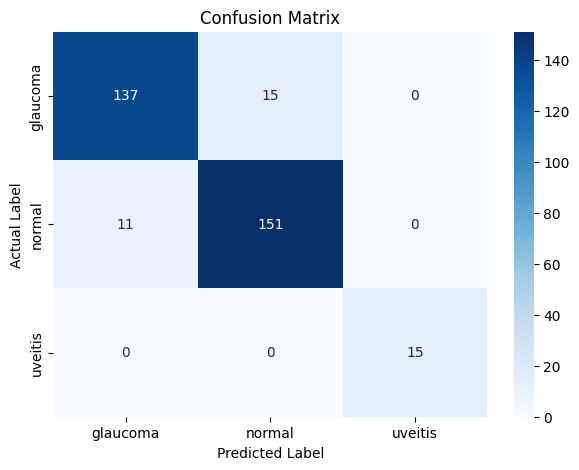

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)

class_names = ['glaucoma', 'normal', 'uveitis']

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()

In [43]:
class EfficientNetBaseline(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.backbone = timm.create_model(
            'tf_efficientnetv2_s',
            pretrained=True,
            num_classes=0
        )

        features = self.backbone.num_features

        self.classifier = nn.Linear(
            features,
            num_classes
        )

    def forward(self, x):
        features = self.backbone(x)
        output = self.classifier(features)
        return output

In [44]:
efficientnet_baseline = EfficientNetBaseline(
    num_classes=3
).to(device)

print("EfficientNetV2-S baseline created!")

EfficientNetV2-S baseline created!


In [45]:
for param in efficientnet_baseline.backbone.parameters():
    param.requires_grad = False

print("EfficientNetV2-S backbone frozen!")

EfficientNetV2-S backbone frozen!


In [46]:
criterion_eff = nn.CrossEntropyLoss()

optimizer_eff = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        efficientnet_baseline.parameters()
    ),
    lr=0.001,
    weight_decay=0.0001
)

In [47]:
num_epochs = 10

for epoch in range(num_epochs):

    efficientnet_baseline.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_eff.zero_grad()

        outputs = efficientnet_baseline(images)

        loss = criterion_eff(outputs, labels)

        loss.backward()
        optimizer_eff.step()

        train_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_accuracy = train_correct / train_total
    train_epoch_loss = train_loss / train_total

    efficientnet_baseline.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = efficientnet_baseline(images)

            loss = criterion_eff(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_accuracy = val_correct / val_total
    val_epoch_loss = val_loss / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_epoch_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_epoch_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] | Train Loss: 0.4753 | Train Acc: 0.7928 | Val Loss: 0.3527 | Val Acc: 0.8624
Epoch [2/10] | Train Loss: 0.3532 | Train Acc: 0.8459 | Val Loss: 0.3396 | Val Acc: 0.8685
Epoch [3/10] | Train Loss: 0.3144 | Train Acc: 0.8728 | Val Loss: 0.3188 | Val Acc: 0.8685
Epoch [4/10] | Train Loss: 0.3013 | Train Acc: 0.8689 | Val Loss: 0.3186 | Val Acc: 0.8654
Epoch [5/10] | Train Loss: 0.2917 | Train Acc: 0.8721 | Val Loss: 0.3185 | Val Acc: 0.8746
Epoch [6/10] | Train Loss: 0.2877 | Train Acc: 0.8734 | Val Loss: 0.3151 | Val Acc: 0.8654
Epoch [7/10] | Train Loss: 0.2929 | Train Acc: 0.8767 | Val Loss: 0.3075 | Val Acc: 0.8563
Epoch [8/10] | Train Loss: 0.3046 | Train Acc: 0.8741 | Val Loss: 0.3594 | Val Acc: 0.8563
Epoch [9/10] | Train Loss: 0.2923 | Train Acc: 0.8820 | Val Loss: 0.3070 | Val Acc: 0.8624
Epoch [10/10] | Train Loss: 0.3100 | Train Acc: 0.8833 | Val Loss: 0.3675 | Val Acc: 0.8685


In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

efficientnet_baseline.eval()

eff_labels = []
eff_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_baseline(images)

        predictions = torch.argmax(outputs, dim=1)

        eff_labels.extend(labels.cpu().numpy())
        eff_predictions.extend(predictions.cpu().numpy())

eff_accuracy = accuracy_score(
    eff_labels,
    eff_predictions
)

eff_precision = precision_score(
    eff_labels,
    eff_predictions,
    average='macro',
    zero_division=0
)

eff_recall = recall_score(
    eff_labels,
    eff_predictions,
    average='macro',
    zero_division=0
)

eff_f1 = f1_score(
    eff_labels,
    eff_predictions,
    average='macro',
    zero_division=0
)

print(f"EfficientNet Test Accuracy : {eff_accuracy:.4f}")
print(f"EfficientNet Test Precision: {eff_precision:.4f}")
print(f"EfficientNet Test Recall   : {eff_recall:.4f}")
print(f"EfficientNet Test F1-score : {eff_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        eff_labels,
        eff_predictions,
        target_names=['glaucoma', 'normal', 'uveitis'],
        zero_division=0
    )
)

EfficientNet Test Accuracy : 0.9027
EfficientNet Test Precision: 0.9372
EfficientNet Test Recall   : 0.9306
EfficientNet Test F1-score : 0.9314

Classification Report:

              precision    recall  f1-score   support

    glaucoma       0.95      0.83      0.89       152
      normal       0.86      0.96      0.91       162
     uveitis       1.00      1.00      1.00        15

    accuracy                           0.90       329
   macro avg       0.94      0.93      0.93       329
weighted avg       0.91      0.90      0.90       329



In [49]:
class DenseNetBaseline(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.backbone = timm.create_model(
            'densenet201',
            pretrained=True,
            num_classes=0
        )

        features = self.backbone.num_features

        self.classifier = nn.Linear(
            features,
            num_classes
        )

    def forward(self, x):
        features = self.backbone(x)
        output = self.classifier(features)
        return output

In [50]:
densenet_baseline = DenseNetBaseline(
    num_classes=3
).to(device)

print("DenseNet-201 baseline created!")

DenseNet-201 baseline created!


In [51]:
for param in densenet_baseline.backbone.parameters():
    param.requires_grad = False

print("DenseNet-201 backbone frozen!")

DenseNet-201 backbone frozen!


In [52]:
criterion_dense = nn.CrossEntropyLoss()

optimizer_dense = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        densenet_baseline.parameters()
    ),
    lr=0.001,
    weight_decay=0.0001
)

print("DenseNet loss and optimizer ready!")

DenseNet loss and optimizer ready!


In [53]:
num_epochs = 10

for epoch in range(num_epochs):

    densenet_baseline.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_dense.zero_grad()

        outputs = densenet_baseline(images)

        loss = criterion_dense(outputs, labels)

        loss.backward()
        optimizer_dense.step()

        train_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_accuracy = train_correct / train_total
    train_epoch_loss = train_loss / train_total

    densenet_baseline.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = densenet_baseline(images)

            loss = criterion_dense(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_accuracy = val_correct / val_total
    val_epoch_loss = val_loss / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_epoch_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_epoch_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] | Train Loss: 0.5616 | Train Acc: 0.7626 | Val Loss: 0.3961 | Val Acc: 0.8379
Epoch [2/10] | Train Loss: 0.3480 | Train Acc: 0.8544 | Val Loss: 0.3255 | Val Acc: 0.8838
Epoch [3/10] | Train Loss: 0.3607 | Train Acc: 0.8380 | Val Loss: 0.3327 | Val Acc: 0.8685
Epoch [4/10] | Train Loss: 0.3207 | Train Acc: 0.8682 | Val Loss: 0.2916 | Val Acc: 0.8991
Epoch [5/10] | Train Loss: 0.3185 | Train Acc: 0.8689 | Val Loss: 0.3338 | Val Acc: 0.8593
Epoch [6/10] | Train Loss: 0.3061 | Train Acc: 0.8662 | Val Loss: 0.3264 | Val Acc: 0.8746
Epoch [7/10] | Train Loss: 0.2639 | Train Acc: 0.8839 | Val Loss: 0.2898 | Val Acc: 0.8869
Epoch [8/10] | Train Loss: 0.2830 | Train Acc: 0.8800 | Val Loss: 0.2741 | Val Acc: 0.8991
Epoch [9/10] | Train Loss: 0.2999 | Train Acc: 0.8708 | Val Loss: 0.3396 | Val Acc: 0.8746
Epoch [10/10] | Train Loss: 0.2705 | Train Acc: 0.8852 | Val Loss: 0.2804 | Val Acc: 0.8777


In [54]:
densenet_baseline.eval()

dense_labels = []
dense_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = densenet_baseline(images)

        predictions = torch.argmax(outputs, dim=1)

        dense_labels.extend(labels.cpu().numpy())
        dense_predictions.extend(predictions.cpu().numpy())

dense_accuracy = accuracy_score(
    dense_labels,
    dense_predictions
)

dense_precision = precision_score(
    dense_labels,
    dense_predictions,
    average='macro',
    zero_division=0
)

dense_recall = recall_score(
    dense_labels,
    dense_predictions,
    average='macro',
    zero_division=0
)

dense_f1 = f1_score(
    dense_labels,
    dense_predictions,
    average='macro',
    zero_division=0
)

print(f"DenseNet Test Accuracy : {dense_accuracy:.4f}")
print(f"DenseNet Test Precision: {dense_precision:.4f}")
print(f"DenseNet Test Recall   : {dense_recall:.4f}")
print(f"DenseNet Test F1-score : {dense_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        dense_labels,
        dense_predictions,
        target_names=['glaucoma', 'normal', 'uveitis'],
        zero_division=0
    )
)

DenseNet Test Accuracy : 0.8936
DenseNet Test Precision: 0.9264
DenseNet Test Recall   : 0.9251
DenseNet Test F1-score : 0.9255

Classification Report:

              precision    recall  f1-score   support

    glaucoma       0.90      0.86      0.88       152
      normal       0.88      0.91      0.89       162
     uveitis       1.00      1.00      1.00        15

    accuracy                           0.89       329
   macro avg       0.93      0.93      0.93       329
weighted avg       0.89      0.89      0.89       329



In [55]:
class FusionWithoutAttention(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.efficientnet = timm.create_model(
            'tf_efficientnetv2_s',
            pretrained=True,
            num_classes=0
        )

        self.densenet = timm.create_model(
            'densenet201',
            pretrained=True,
            num_classes=0
        )

        efficientnet_features = self.efficientnet.num_features
        densenet_features = self.densenet.num_features

        fusion_features = (
            efficientnet_features + densenet_features
        )

        self.classifier = nn.Sequential(
            nn.Linear(fusion_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        efficientnet_features = self.efficientnet(x)

        densenet_features = self.densenet(x)

        fused_features = torch.cat(
            [
                efficientnet_features,
                densenet_features
            ],
            dim=1
        )

        output = self.classifier(fused_features)

        return output

In [56]:
fusion_no_attention = FusionWithoutAttention(
    num_classes=3
).to(device)

print("Fusion without Attention model created!")

Fusion without Attention model created!


In [57]:
for param in fusion_no_attention.efficientnet.parameters():
    param.requires_grad = False

for param in fusion_no_attention.densenet.parameters():
    param.requires_grad = False

print("Both pretrained backbones frozen!")

Both pretrained backbones frozen!


In [58]:
criterion_fusion = nn.CrossEntropyLoss()

optimizer_fusion = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        fusion_no_attention.parameters()
    ),
    lr=0.001,
    weight_decay=0.0001
)

print("Fusion loss and optimizer ready!")

Fusion loss and optimizer ready!


In [59]:
num_epochs = 10

for epoch in range(num_epochs):

    fusion_no_attention.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_fusion.zero_grad()

        outputs = fusion_no_attention(images)

        loss = criterion_fusion(outputs, labels)

        loss.backward()
        optimizer_fusion.step()

        train_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_epoch_loss = train_loss / train_total
    train_accuracy = train_correct / train_total

    fusion_no_attention.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = fusion_no_attention(images)

            loss = criterion_fusion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_loss / val_total
    val_accuracy = val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_epoch_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_epoch_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] | Train Loss: 0.5410 | Train Acc: 0.7508 | Val Loss: 0.2911 | Val Acc: 0.8777
Epoch [2/10] | Train Loss: 0.3915 | Train Acc: 0.8348 | Val Loss: 0.2841 | Val Acc: 0.8777
Epoch [3/10] | Train Loss: 0.3347 | Train Acc: 0.8525 | Val Loss: 0.2676 | Val Acc: 0.8899
Epoch [4/10] | Train Loss: 0.3148 | Train Acc: 0.8643 | Val Loss: 0.2990 | Val Acc: 0.8838
Epoch [5/10] | Train Loss: 0.3013 | Train Acc: 0.8767 | Val Loss: 0.2657 | Val Acc: 0.8838
Epoch [6/10] | Train Loss: 0.2972 | Train Acc: 0.8800 | Val Loss: 0.2693 | Val Acc: 0.8807
Epoch [7/10] | Train Loss: 0.3065 | Train Acc: 0.8616 | Val Loss: 0.2600 | Val Acc: 0.8869
Epoch [8/10] | Train Loss: 0.2645 | Train Acc: 0.8846 | Val Loss: 0.2620 | Val Acc: 0.8746
Epoch [9/10] | Train Loss: 0.2751 | Train Acc: 0.8741 | Val Loss: 0.2980 | Val Acc: 0.8685
Epoch [10/10] | Train Loss: 0.2389 | Train Acc: 0.8990 | Val Loss: 0.3953 | Val Acc: 0.8532


In [60]:
fusion_no_attention.eval()

fusion_labels = []
fusion_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = fusion_no_attention(images)

        predictions = torch.argmax(outputs, dim=1)

        fusion_labels.extend(labels.cpu().numpy())
        fusion_predictions.extend(predictions.cpu().numpy())

fusion_accuracy = accuracy_score(
    fusion_labels,
    fusion_predictions
)

fusion_precision = precision_score(
    fusion_labels,
    fusion_predictions,
    average='macro',
    zero_division=0
)

fusion_recall = recall_score(
    fusion_labels,
    fusion_predictions,
    average='macro',
    zero_division=0
)

fusion_f1 = f1_score(
    fusion_labels,
    fusion_predictions,
    average='macro',
    zero_division=0
)

print(f"Fusion Without Attention Test Accuracy : {fusion_accuracy:.4f}")
print(f"Fusion Without Attention Test Precision: {fusion_precision:.4f}")
print(f"Fusion Without Attention Test Recall   : {fusion_recall:.4f}")
print(f"Fusion Without Attention Test F1-score : {fusion_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        fusion_labels,
        fusion_predictions,
        target_names=['glaucoma', 'normal', 'uveitis'],
        zero_division=0
    )
)

Fusion Without Attention Test Accuracy : 0.8754
Fusion Without Attention Test Precision: 0.9307
Fusion Without Attention Test Recall   : 0.9102
Fusion Without Attention Test F1-score : 0.9108

Classification Report:

              precision    recall  f1-score   support

    glaucoma       0.99      0.74      0.85       152
      normal       0.80      0.99      0.89       162
     uveitis       1.00      1.00      1.00        15

    accuracy                           0.88       329
   macro avg       0.93      0.91      0.91       329
weighted avg       0.90      0.88      0.87       329



In [61]:
# Save the proposed model

torch.save(
    model.state_dict(),
    "/content/proposed_fusion_attention_model.pth"
)

print("Proposed model saved successfully!")

Proposed model saved successfully!


In [62]:
# Save the proposed model to Google Drive

torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/proposed_fusion_attention_model.pth"
)

print("Proposed model saved successfully to Google Drive!")

Proposed model saved successfully to Google Drive!


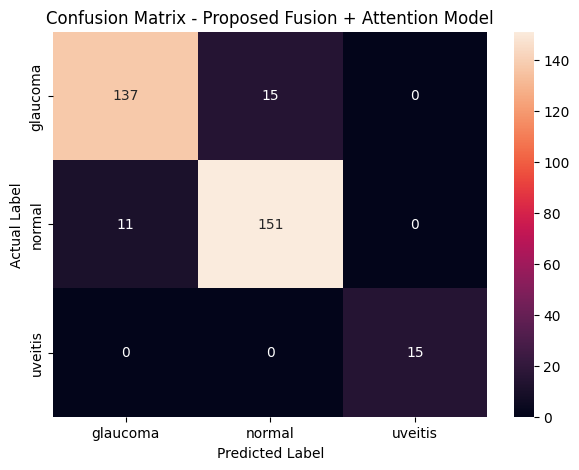

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Proposed model evaluation
model.eval()

true_labels = []
predicted_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        true_labels.extend(labels.numpy())
        predicted_labels.extend(predictions.cpu().numpy())

# Class names
class_names = test_dataset.classes

# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Proposed Fusion + Attention Model")
plt.show()

In [64]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [65]:
print("EfficientNet last layers:")
print(model.efficientnet)

print("\nDenseNet last layers:")
print(model.densenet)

EfficientNet last layers:
EfficientNet(
  (conv_stem): Conv2dSame(3, 24, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Ident

In [66]:
model.efficientnet.conv_head

Conv2d(256, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)

In [67]:
model.densenet.features.norm5

BatchNormAct2d(
  1920, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
  (drop): Identity()
  (act): ReLU(inplace=True)
)

In [68]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import numpy as np
import matplotlib.pyplot as plt

In [69]:
# Use only one target layer first
target_layers = [model.efficientnet.conv_head]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

model.eval()

FusionModel(
  (efficientnet): EfficientNet(
    (conv_stem): Conv2dSame(3, 24, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn1): BatchNormAct2d(
      24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): ConvBnAct(
          (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNormAct2d(
            24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (drop_path): Identity()
        )
        (1): ConvBnAct(
          (conv): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNormAct2d(
            24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (a

Actual class: glaucoma
Predicted class: glaucoma


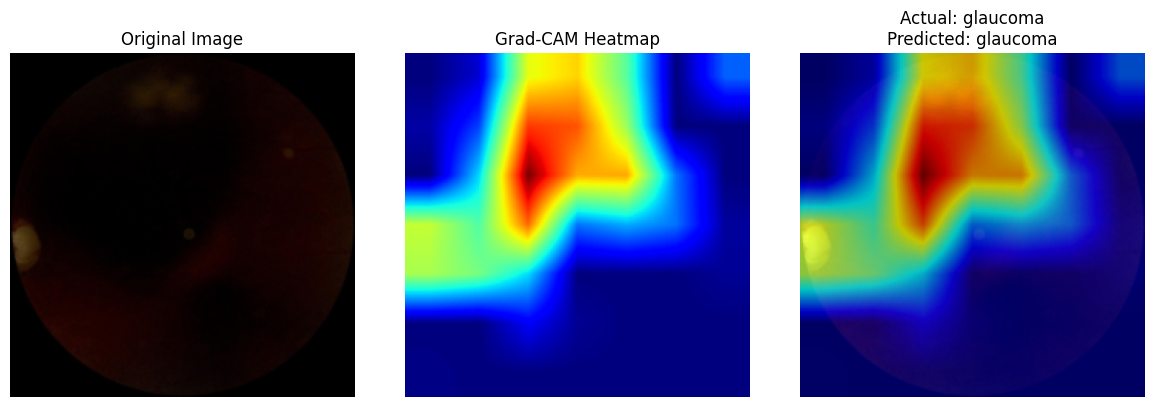

In [70]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Evaluation mode
model.eval()

# Select one target layer
target_layers = [model.efficientnet.conv_head]

# Create Grad-CAM
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

# Get one test image
image, label = test_dataset[0]

# Add batch dimension
input_tensor = image.unsqueeze(0).to(device)

# IMPORTANT:
# Enable gradient for input
input_tensor.requires_grad_(True)

# Prediction
with torch.no_grad():
    output = model(input_tensor)
    predicted_class = torch.argmax(output, dim=1).item()

print("Actual class:", test_dataset.classes[label])
print("Predicted class:", test_dataset.classes[predicted_class])

# Target predicted class
targets = [ClassifierOutputTarget(predicted_class)]

# Generate Grad-CAM
# No torch.no_grad() here
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

# Select first image
grayscale_cam = grayscale_cam[0]

# Convert normalized image back to display format
image_np = image.permute(1, 2, 0).cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image_np = image_np * std + mean
image_np = np.clip(image_np, 0, 1)

# Create heatmap overlay
visualization = show_cam_on_image(
    image_np,
    grayscale_cam,
    use_rgb=True
)

# Display results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(grayscale_cam, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(visualization)
plt.title(
    f"Actual: {test_dataset.classes[label]}\n"
    f"Predicted: {test_dataset.classes[predicted_class]}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [71]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

# Class names
class_names = test_dataset.classes

print("Class mapping:", class_names)

# Select 3 images from each class
selected_images = []

for class_index, class_name in enumerate(class_names):

    class_indices = [
        i for i, (_, label) in enumerate(test_dataset.samples)
        if label == class_index
    ]

    random.seed(42)
    selected_indices = random.sample(class_indices, 3)

    for index in selected_indices:
        selected_images.append(index)

print("Selected image indices:", selected_images)

Class mapping: ['glaucoma', 'normal', 'uveitis']
Selected image indices: [28, 6, 70, 180, 158, 222, 324, 315, 314]


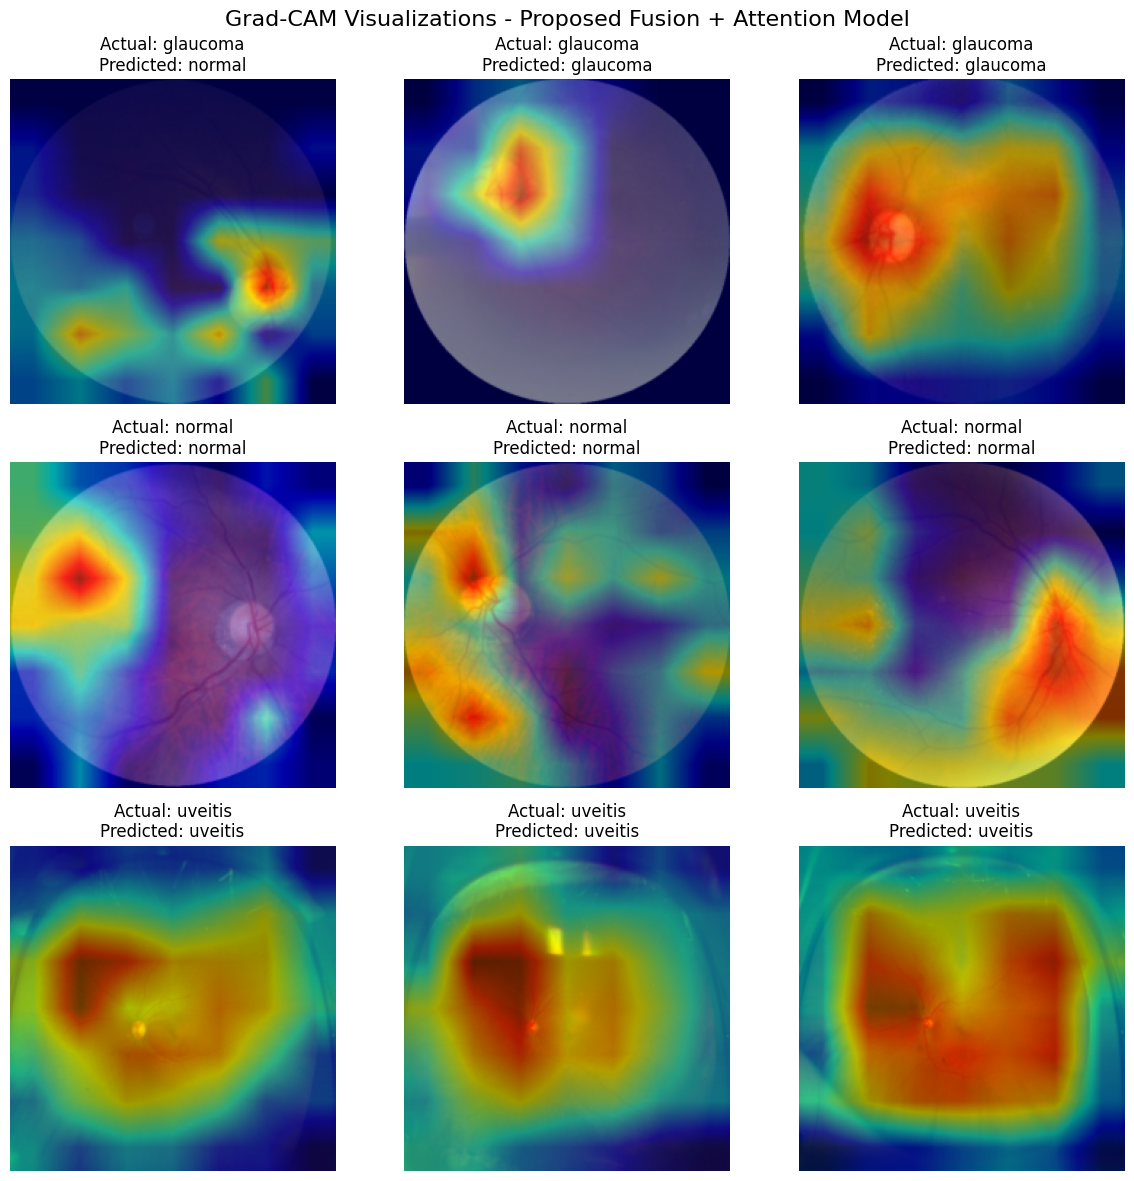

In [72]:
# Make sure model is in evaluation mode
model.eval()

# Enable gradients for Grad-CAM
for param in model.efficientnet.parameters():
    param.requires_grad = True

for param in model.densenet.parameters():
    param.requires_grad = True

# Use EfficientNet target layer
target_layers = [model.efficientnet.conv_head]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

# Create figure
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 12)
)

for plot_index, image_index in enumerate(selected_images):

    image, actual_label = test_dataset[image_index]

    # Add batch dimension
    input_tensor = image.unsqueeze(0).to(device)
    input_tensor.requires_grad_(True)

    # Prediction
    with torch.no_grad():
        output = model(input_tensor)
        predicted_class = torch.argmax(output, dim=1).item()

    # Grad-CAM target
    targets = [
        ClassifierOutputTarget(predicted_class)
    ]

    # Generate Grad-CAM
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    # Convert normalized image back
    image_np = image.permute(1, 2, 0).cpu().numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image_np = image_np * std + mean
    image_np = np.clip(image_np, 0, 1)

    # Display heatmap overlay
    visualization = show_cam_on_image(
        image_np,
        grayscale_cam,
        use_rgb=True
    )

    # Plot
    row = plot_index // 3
    col = plot_index % 3

    axes[row, col].imshow(visualization)

    axes[row, col].set_title(
        f"Actual: {class_names[actual_label]}\n"
        f"Predicted: {class_names[predicted_class]}"
    )

    axes[row, col].axis("off")

plt.suptitle(
    "Grad-CAM Visualizations - Proposed Fusion + Attention Model",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [73]:
target_layers = [model.efficientnet.conv_head]

In [74]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import torch

In [75]:
model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Model output
        outputs = model(images)

        # Convert logits into probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Predicted class
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print("Predictions collected successfully!")
print("Labels shape:", all_labels.shape)
print("Probabilities shape:", all_probabilities.shape)

Predictions collected successfully!
Labels shape: (329,)
Probabilities shape: (329, 3)


In [76]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

balanced_accuracy = balanced_accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

# Multiclass ROC-AUC
roc_auc = roc_auc_score(
    all_labels,
    all_probabilities,
    multi_class="ovr",
    average="macro"
)

print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced Accuracy : {balanced_accuracy:.4f}")
print(f"Macro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1-score    : {macro_f1:.4f}")
print(f"Macro ROC-AUC     : {roc_auc:.4f}")

Accuracy          : 0.9210
Balanced Accuracy : 0.9445
Macro Precision   : 0.9451
Macro Recall      : 0.9445
Macro F1-score    : 0.9447
Macro ROC-AUC     : 0.9822


In [77]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[137  15   0]
 [ 11 151   0]
 [  0   0  15]]


In [78]:
class_names = test_dataset.classes

print("\nClass-wise Metrics:\n")

for i, class_name in enumerate(class_names):

    true_positive = cm[i, i]

    false_negative = cm[i, :].sum() - true_positive
    false_positive = cm[:, i].sum() - true_positive

    true_negative = cm.sum() - (
        true_positive +
        false_negative +
        false_positive
    )

    sensitivity = true_positive / (
        true_positive + false_negative
    ) if (true_positive + false_negative) > 0 else 0

    specificity = true_negative / (
        true_negative + false_positive
    ) if (true_negative + false_positive) > 0 else 0

    print(f"{class_name}")
    print(f"  Sensitivity : {sensitivity:.4f}")
    print(f"  Specificity : {specificity:.4f}")
    print()


Class-wise Metrics:

glaucoma
  Sensitivity : 0.9013
  Specificity : 0.9379

normal
  Sensitivity : 0.9321
  Specificity : 0.9102

uveitis
  Sensitivity : 1.0000
  Specificity : 1.0000



In [79]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Convert actual labels into one-hot format
y_true_binary = label_binarize(
    all_labels,
    classes=[0, 1, 2]
)

# Calculate macro ROC-AUC
macro_roc_auc = roc_auc_score(
    y_true_binary,
    all_probabilities,
    multi_class="ovr",
    average="macro"
)

print(f"Macro ROC-AUC: {macro_roc_auc:.4f}")

Macro ROC-AUC: 0.9822


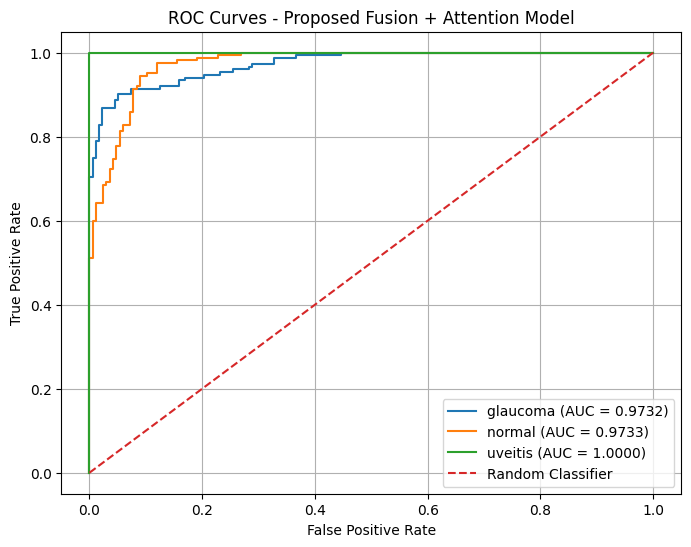

In [80]:
class_names = test_dataset.classes

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):

    false_positive_rate, true_positive_rate, thresholds = roc_curve(
        y_true_binary[:, i],
        all_probabilities[:, i]
    )

    class_auc = auc(
        false_positive_rate,
        true_positive_rate
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{class_name} (AUC = {class_auc:.4f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Proposed Fusion + Attention Model")
plt.legend()
plt.grid()
plt.show()

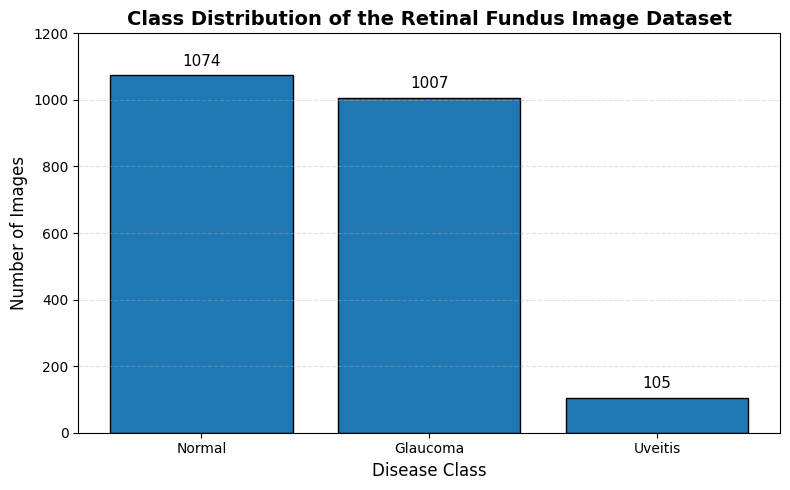

In [81]:
import matplotlib.pyplot as plt

# Dataset class counts
class_names = ['Normal', 'Glaucoma', 'Uveitis']
class_counts = [1074, 1007, 105]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    class_names,
    class_counts,
    edgecolor='black'
)

# Display count above each bar
for bar, count in zip(bars, class_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        str(count),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

plt.title(
    'Class Distribution of the Retinal Fundus Image Dataset',
    fontsize=14,
    fontweight='bold'
)

plt.ylim(0, 1200)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

# Save figure for paper
plt.savefig(
    '/content/dataset_class_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()